J. Heaton class Part 10.5: Programming Transformers with Keras recommends

https://keras.io/examples/timeseries/timeseries_classification_transformer/

and on this page, TimeSeries Classification from Scratch is recommended

https://keras.io/examples/timeseries/timeseries_classification_from_scratch/


In [1]:
import numpy as np
import keras
from keras import layers
import os
import matplotlib.pyplot as plt

BASE_PATH = "../../../../../local_data/practice/keras/transformers/"
DATA_PATH = BASE_PATH + "timeseries/"
OUTPUT_PATH = BASE_PATH + "timeseries/"

os.system("mkdir -p " + OUTPUT_PATH)

# to place datafiles in local folder:
# cd (wherever your local_data folder is)
# cd practice/keras/transformers
# wget https://raw.githubusercontent.com/hfawaz/cd-diagram/master/FordA/FordA_TRAIN.tsv
# wget https://raw.githubusercontent.com/hfawaz/cd-diagram/master/FordA/FordA_TEST.tsv


def readucr(filename):
    data = np.loadtxt(filename, delimiter="\t")
    y = data[:, 0]
    x = data[:, 1:]
    return x, y.astype(int)


# root_url = "https://raw.githubusercontent.com/hfawaz/cd-diagram/master/FordA/"
root_url = DATA_PATH

x_train, y_train = readucr(root_url + "FordA_TRAIN.tsv")
x_test, y_test = readucr(root_url + "FordA_TEST.tsv")

# print(x_train)
# print(y_train)

2026-03-20 20:44:43.420236: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-03-20 20:44:43.420275: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-03-20 20:44:43.421299: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-03-20 20:44:43.427242: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


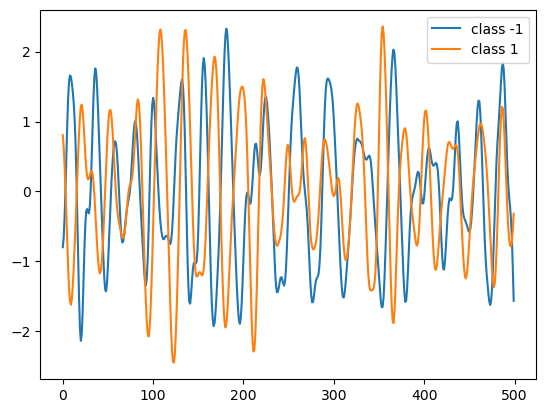

In [2]:
classes = np.unique(np.concatenate((y_train, y_test), axis=0))

plt.figure()
for c in classes:
    c_x_train = x_train[y_train == c]
    plt.plot(c_x_train[0], label="class " + str(c))
plt.legend(loc="best")
plt.show()
plt.close()

In [3]:
# subset for debugging
# n_data=3
# x_train = x_train[:n_data]
# y_train = y_train[:n_data]
# print("x_train after subset\n",x_train)

In [4]:
print("x_train shape before reshape",x_train.shape)
# print("x_train[0] before reshape\n",x_train[0])
# print("x_train before reshape\n",x_train)
x_train = x_train.reshape((x_train.shape[0], x_train.shape[1], 1))
x_test = x_test.reshape((x_test.shape[0], x_test.shape[1], 1))
print("x_train shape after reshape",x_train.shape)
# print("x_train[0] after reshape\n",x_train[0])
# print("x_train after reshape\n",x_train)

num_classes = len(np.unique(y_train))
# print(n_classes)

idx = np.random.permutation(len(x_train))
# print(idx)
x_train = x_train[idx]
y_train = y_train[idx]
# print("x_train after shuffling\n",x_train)


y_train[y_train == -1] = 0
y_test[y_test == -1] = 0

x_train shape before reshape (3601, 500)
x_train shape after reshape (3601, 500, 1)


2026-03-20 20:44:45.589130: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 22462 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3090, pci bus id: 0000:81:00.0, compute capability: 8.6
2026-03-20 20:44:45.589796: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 22462 MB memory:  -> device: 1, name: NVIDIA GeForce RTX 3090, pci bus id: 0000:c1:00.0, compute capability: 8.6


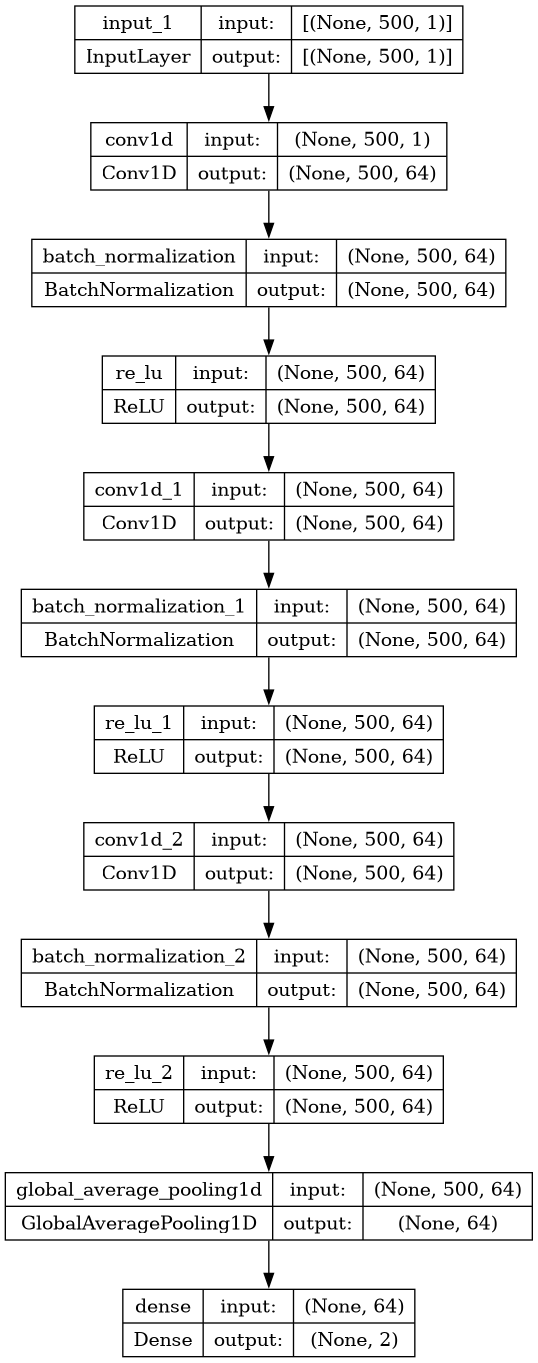

In [5]:
def make_model(input_shape):
    input_layer = keras.layers.Input(input_shape)

    conv1 = keras.layers.Conv1D(filters=64, kernel_size=3, padding="same")(input_layer)
    conv1 = keras.layers.BatchNormalization()(conv1)
    conv1 = keras.layers.ReLU()(conv1)

    conv2 = keras.layers.Conv1D(filters=64, kernel_size=3, padding="same")(conv1)
    conv2 = keras.layers.BatchNormalization()(conv2)
    conv2 = keras.layers.ReLU()(conv2)

    conv3 = keras.layers.Conv1D(filters=64, kernel_size=3, padding="same")(conv2)
    conv3 = keras.layers.BatchNormalization()(conv3)
    conv3 = keras.layers.ReLU()(conv3)

    gap = keras.layers.GlobalAveragePooling1D()(conv3)

    output_layer = keras.layers.Dense(num_classes, activation="softmax")(gap)

    return keras.models.Model(inputs=input_layer, outputs=output_layer)


model = make_model(input_shape=x_train.shape[1:])
keras.utils.plot_model(model, show_shapes=True)